<a href="https://colab.research.google.com/github/Pranjali2003/CPoint_DataAnalytics/blob/Main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("kasikrit/att-database-of-faces")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'att-database-of-faces' dataset.
Path to dataset files: /kaggle/input/att-database-of-faces


In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

standardize_image_vector = None

In [ ]:
# read the image and standardize it to 1D
def load_image_from_folder(folder,sub_folder_count):
    images = []
    while sub_folder_count:
        subfolder_path = os.path.join(folder, f"s{sub_folder_count}")
        for file in os.listdir(subfolder_path):
            if file.endswith(".pgm"):
                img = cv2.imread(os.path.join(subfolder_path, file),cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    images.append(img.flatten())
        sub_folder_count-=1
    return np.array(images,dtype=np.float32)

#centering the data
def center_the_matrix_data(matrix_data):
    # calculating the mean column wise
    mean_vector = np.mean(matrix_data, axis=0)
    # centering the data
    centered_data = matrix_data - mean_vector
    return centered_data

In [ ]:
def plot_and_visualize_data(data,centered_data):
    # The plot is intended for a subset of rows and columns for clear visualization
    n_plot = 5
    m_plot_display = 5 # Displaying the first 5 columns

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    fig.suptitle("Mean Centering — NxM Matrix (First 5 Rows, First 5 Columns)", fontsize=14, fontweight='bold')
    # Pass the correct number of rows (n_plot) and the limited number of columns (m_plot_display)
    plot_matrix(axes[0], data[:n_plot, :m_plot_display],"Raw matrix",n_plot,m_plot_display)
    plot_matrix(axes[1], centered_data[:n_plot, :m_plot_display], "Mean-centered matrix",n_plot,m_plot_display)
    plt.tight_layout()
    plt.show() # Display the plot instead of saving
    return True

def plot_matrix(ax, mat, title,n,m):
    for j in range(m):
        col_vals = mat[:, j]
        col_x     = np.arange(n) * m + j
        # Removed 'label=f'col {j}' to optimize legend for large datasets
        ax.stem(col_x, col_vals,
                linefmt=f'C{j}-', markerfmt=f'C{j}o', basefmt='k-')
    mean_val = np.mean(mat)
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.4,
               label=f'overall mean = {mean_val:.2f}')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Row index (grouped by column color)")
    ax.set_ylabel("Value")
    ax.set_xticks([i * m + (m - 1) / 2 for i in range(n)])
    ax.set_xticklabels([f'row {i}' for i in range(n)])
    # Only show legend if there are meaningful labels (e.g., only 'overall mean')
    if ax.get_legend_handles_labels()[1]:
        ax.legend(fontsize=8)

Executing Script...............
(300, 10304)


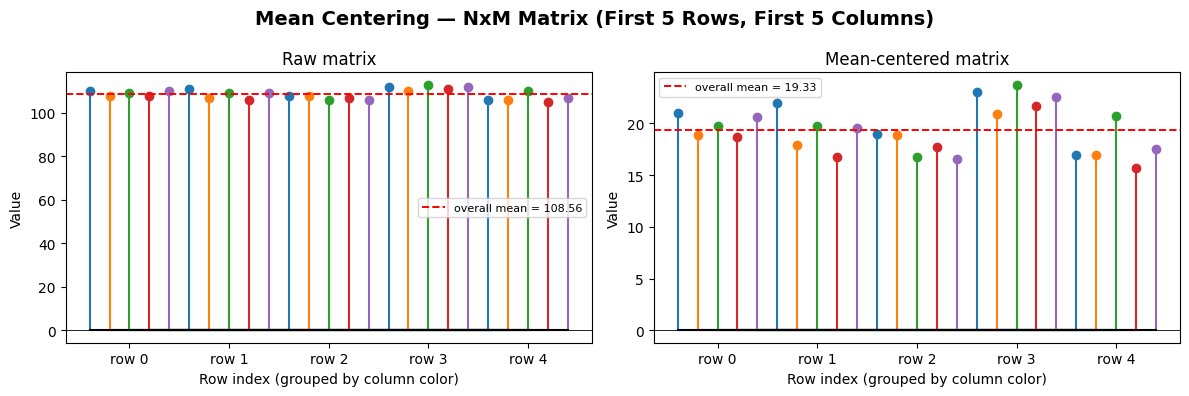

In [ ]:
if __name__ == "__main__":
    print('Executing Script...............')
    sub_folder_count = 30
    standardize_image_vector = load_image_from_folder(path,sub_folder_count)
    print(standardize_image_vector.shape)
    centered_standardize_image_vector = center_the_matrix_data(standardize_image_vector)
    plot_and_visualize_data(standardize_image_vector, centered_standardize_image_vector)